____
# Spatial scales


In [6]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import put_fig_letter, update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error, extract_mean_geo

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [7]:
dt=3
distance_to_coast_max = 20e3
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
max_ggd = 1e-4
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

In [3]:
dd = pd.read_csv('/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/coloc_files/alti/alticoloc_swot2km_gaussian_30000_12h_spectral_decomp_all_med_variational_10min_v0.csv')

In [4]:
dd

,row_number,cycle_number,longitude,latitude,filtered_etaf,dx_etaf,dy_etaf,dxx_etaf,dyy_etaf,dxy_etaf,...,dyy_etafm,dxy_etafm,filtered_etacm,dx_etacm,dy_etacm,dxx_etacm,dyy_etacm,dxy_etacm,cutoff,pass_number
0,0,478,4.811970,42.220893,-0.119658,-3.817767e-07,2.957781e-07,-1.114827e-11,2.226016e-13,-2.771219e-12,...,1.517073e-12,-5.025556e-12,-0.214085,-2.956013e-07,3.215646e-07,-1.376075e-11,7.850712e-13,-5.145155e-12,30000,3
1,1,478,4.812432,42.221430,-0.119653,-3.833764e-07,2.955801e-07,-1.113034e-11,1.498271e-13,-2.788600e-12,...,1.452112e-12,-5.041590e-12,-0.214068,-2.979154e-07,3.212032e-07,-1.378901e-11,7.162717e-13,-5.161115e-12,30000,3
2,2,478,4.812916,42.221930,-0.119638,-3.835800e-07,2.955700e-07,-1.111984e-11,1.361253e-13,-2.801897e-12,...,1.440061e-12,-5.053087e-12,-0.214051,-2.982609e-07,3.212149e-07,-1.378105e-11,7.036811e-13,-5.173463e-12,30000,3
3,3,478,4.813418,42.222394,-0.119624,-3.838203e-07,2.955505e-07,-1.110958e-11,1.212071e-13,-2.815131e-12,...,1.426943e-12,-5.064575e-12,-0.214035,-2.986545e-07,3.212116e-07,-1.377447e-11,6.899556e-13,-5.185764e-12,30000,3
4,4,478,4.813933,42.222825,-0.119610,-3.840933e-07,2.955223e-07,-1.109957e-11,1.052131e-13,-2.828271e-12,...,1.412881e-12,-5.076020e-12,-0.214019,-2.990906e-07,3.211944e-07,-1.376916e-11,6.752240e-13,-5.197987e-12,30000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374705,376718,577,2.417786,39.788394,0.021066,2.285815e-07,5.532732e-07,1.611802e-11,3.800659e-11,5.745641e-13,...,4.357789e-11,5.045167e-12,-0.055948,1.101035e-07,6.839004e-07,1.416845e-11,4.499659e-11,4.464525e-12,30000,16
374706,376719,577,2.416881,39.788885,0.021044,2.292602e-07,5.511187e-07,1.616177e-11,3.791933e-11,5.632070e-13,...,4.348405e-11,5.029503e-12,-0.055982,1.104747e-07,6.815140e-07,1.419535e-11,4.490261e-11,4.449248e-12,30000,16
374707,376720,577,2.415948,39.789399,0.021015,2.298898e-07,5.484918e-07,1.620985e-11,3.781550e-11,5.551053e-13,...,4.337000e-11,5.014367e-12,-0.056025,1.107519e-07,6.785546e-07,1.422497e-11,4.478835e-11,4.434380e-12,30000,16
374708,376721,577,2.414994,39.789938,0.020978,2.304935e-07,5.453080e-07,1.626400e-11,3.769183e-11,5.500193e-13,...,4.323219e-11,4.999314e-12,-0.056078,1.109468e-07,6.749273e-07,1.425842e-11,4.465023e-11,4.419490e-12,30000,16


_______
# Gaussian

In [7]:
#GAUSSIAN
cutoff = list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3))

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key= alti_product_key,
        alti_diff_method = 'gaussian',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(ct))) for ct in cutoff]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',cutoff)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DSG = extract_mean_geo(DSG)

DSG = DSG.rename({'id_comb':'cutoff'})
DSG['cutoff'] = DSG.cutoff/1000
DSG['cutoff'] = DSG['cutoff'].assign_attrs({'long_name': 'Gaussian filter cutoff', 'units':'km'})

# Closure figs
dsg = compute_mean_square(DSG)/U2



311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_4000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_6000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_8000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_10000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_12000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_14000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_16000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_18000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_20000_etaf__era5_rio0
311439
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_gaussian_25000_etaf__era5_rio0
311439
12h_spectral_dec

In [8]:
dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'gaussian_{colocs_sources}_filtered.nc'))

In [6]:
dsg.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'gaussian_{colocs_sources}_calibrated.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


## If already computed

In [8]:
dsgf = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'gaussian_{colocs_sources}_filtered.nc'))
dsgc = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'gaussian_{colocs_sources}_calibrated.nc'))

In [9]:
# No filter point

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'xarray_diff',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')
comb_list = [base_dic, update_dict(base_dic, {'ggd_var':'etac'})]
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',['filtered', 'calibrated'])
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth='15')) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',['filtered', 'calibrated'])
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSH = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DSH = extract_mean_geo(DSH)

# Closure figs
dsh = compute_mean_square(DSH)/U2

300939
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etaf__era5_rio0
303001
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etac__era5_rio0
Identified SWOT and drifter outliers have been removed
300939
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etaf__era5_rio15
303001
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etac__era5_rio15
Identified SWOT and drifter outliers have been removed
ok
geostrophic mean corrections


In [10]:
dsh['cutoff'] = xr.DataArray([0], dims='cutoff')
dsh = dsh.set_coords('cutoff')

In [11]:
dsgc = xr.concat([dsh.sel(id_comb='calibrated'), dsgc], dim='cutoff')
dsgf = xr.concat([dsh.sel(id_comb='filtered'), dsgf], dim='cutoff')

## L4

In [12]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [base_dic, 
             update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
             update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
             update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),    
]

l = ['L3-SWOT 2km', 'L4_noswot_regional', 'L4_noswot_global', 'L4_withnadirswot']

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
comb_list = [update_dict(c, dict(wd_depth='15')) for c in comb_list]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DS4 = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DS4 = extract_mean_geo(DS4)

DS4 = DS4.rename({'id_comb':'altiprod'})
DS4['altiprod'] = DS4['altiprod'].assign_attrs({'long_name': 'Altimetric products'})

# Closure figs
ds4 = compute_mean_square(DS4)/U2

307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
368591
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_global_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
373036
12h_spectral_decomp_all_med_variational_10min_v0____L4_withnadirswot_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio15
only 'fromduacsv' method is available for L4
368591
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_glo

In [18]:
DS4.latitude.mean()

<xarray.DataArray 'latitude' ()> Size: 8B
array(40.43502015)

In [21]:
DS4['altiprod'] = ['L3-2km', 'L4-regional', 'L4-global', 'L4-SWOT-nadir']
ds4 = compute_mean_square(DS4)/U2

ok
geostrophic mean corrections


# Diagnoses

In [40]:
# Theoritical estimation from chelton 2024 (eq 3b chelton 2022)
def theoritical_chelton(cutoff, sigmassh, cor=3.1e-3):
    # eq 3d chelton 2022 + estimation correlation Chelton2024
    g=9.81
    return 2*g**2*(1-cor)*sigmassh**2/(cutoff**2)

def fit_chelton(cutoff, sigmassh, cor=3.1e-3):
    # eq 3-5 Chelton 2024
    g=9.81
    f37 = 2 * 2 * np.pi / 86164.1 * np.sin(37* np.pi / 180)
    alphauv = 13.86
    return sigmassh**2/0.4*alphauv/(cutoff**2)#*(f37**2)


from scipy.optimize import curve_fit
# Exp fit for balanced contributions
def exp_fit(cutoff, a, b):
    return a*np.exp(-cutoff/b)
cutoff = xr.DataArray(data = np.arange(0, 55, 1), 
                      dims=["cutoff"],
                      name='cutoff'
                     )
b_exp_popt, b_pcov = curve_fit(exp_fit, dsgf.cutoff, dsgf.B_ggd)
b_exp_fit = xr.DataArray(exp_fit(cutoff, *b_exp_popt), coords={'cutoff':cutoff})


In [26]:
ds4

<xarray.Dataset> Size: 5kB
Dimensions:            (altiprod: 4)
Coordinates:
  * altiprod           (altiprod) <U13 208B 'L3-2km' ... 'L4-SWOT-nadir'
Data variables: (12/144)
    ACCn               (altiprod) float64 32B 1.772 1.772 1.772 1.772
    CORn               (altiprod) float64 32B 3.404 3.404 3.404 3.404
    GGDn               (altiprod) float64 32B 1.72 0.5458 0.4098 0.6164
    WDn                (altiprod) float64 32B 0.09896 0.09896 0.09896 0.09896
    Sn                 (altiprod) float64 32B 1.328 1.504 1.559 1.416
    MEANCORn           (altiprod) float64 32B 0.02711 0.02711 0.02711 0.02711
    ...                 ...
    ser__X_cor_wd      (altiprod) float64 32B 0.04282 0.04318 0.04331 0.04319
    ser__X_ggd_wd      (altiprod) float64 32B 0.01664 0.00627 0.005769 0.007173
    ser__D_cyclo       (altiprod) float64 32B 0.0523 0.02481 0.02204 0.02739
    ser__D_anticyclo   (altiprod) float64 32B 0.1056 0.08582 0.08389 0.08711
    ser__MEANCOR       (altiprod) float64 32B 0.0 0.0 0.0 0.0
    ser__MEANGGD       (altiprod) float64 32B 0.0 0.0 0.0 0.0

# Gaussian
## Observed

/dev/shm/pbs.3138621.datarmor0/ipykernel_7877/3034884788.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)
/dev/shm/pbs.3138621.datarmor0/ipykernel_7877/3034884788.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


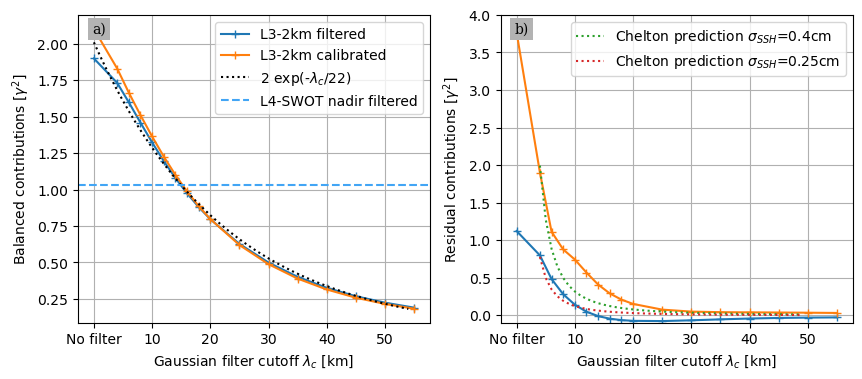

In [49]:
from matplotlib.gridspec import GridSpec

fig, axs = plt.subplots(1, 2, frameon=False, figsize = (10, 4))

ax=axs[0]
dsgf.B_ggd.plot(ax=ax, label = 'L3-2km filtered', marker='+')
dsgc.B_ggd.plot(ax=ax, label = 'L3-2km calibrated', marker='+')
b_exp_fit.plot(ax=ax, ls=':',color='k', label = rf'{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})')
ax.axhline(ds4.sel(altiprod='L4-SWOT-nadir').B_ggd, ls='--',  color=c0['ggd'], label = 'L4-SWOT nadir filtered')
put_fig_letter(fig,ax, 'a')
ax.set_ylabel(r'Balanced contributions [$\gamma^2$]')


ax=axs[1]
dsgf.E_ggd.plot(ax=ax, marker='+')
dsgc.E_ggd.plot(ax=ax, marker='+')
#ax.plot(np.arange(1,50), theoritical_chelton(np.arange(1,50)*1e3, 0.5e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.5cm')
ax.plot(np.arange(4,50), theoritical_chelton(np.arange(4,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton prediction $\sigma_{SSH}$=0.4cm')
#ax.plot(np.arange(1,50), fit_chelton(np.arange(1,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.4cm')
ax.plot(np.arange(4,50), theoritical_chelton(np.arange(4,50)*1e3, 0.25e-2)/U2, ls=':', label ='Chelton prediction $\sigma_{SSH}$=0.25cm')


put_fig_letter(fig,ax,  'b')

ax.set_ylabel(r'Residual contributions [$\gamma^2$]')
ax.set_ylim(-0.1, 4)

for ax in axs :
    a=ax.get_xticks().tolist()
    a = [int(a_) for a_ in a]
    a[1]='No filter'
    ax.set_xticklabels(a)
    ax.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
    ax.grid()
    ax.legend()
    ax.set_title('')

#ins_ax_box = [0.4, 0.30, 0.58, 0.4]
#ins = axs[1].inset_axes(ins_ax_box)
#rc = (dsgf.E_ggd/(dsgf.B_ggd -ds4.sel(altiprod='L4-SWOT-nadir').B_ggd).values)
#rf = (dsgc.E_ggd/(dsgc.B_ggd -ds4.sel(altiprod='L4-SWOT-nadir').B_ggd).values)
#rc.plot(ax=ins, label = 'L3-2km calibrated', marker='+')
#rf.plot(ax=ins, label = 'L3-2km calibrated', marker='+')
#ins.set_xlim(0,14)
#ins.set_ylim(0,5)
#ins.set_title('')
#ins.grid()
#a=ins.get_xticks().tolist()
#a = [int(a_) for a_ in a]
#a[0]='No filter'
#ins.set_xticklabels(a)
#ins.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
#put_fig_letter(fig, ins, 'c')
#ins.set_ylabel(r'$R_{N/A}$')

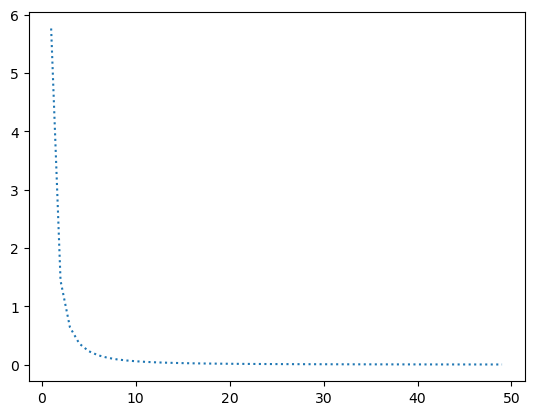

In [41]:
plt.plot(np.arange(1,50), fit_chelton(np.arange(1,50)*1e3, 0.4e-2)/U2, ls=':', label ='Chelton 2024 $\sigma_{SSH}$=0.4cm')


/dev/shm/pbs.3134087.datarmor0/ipykernel_30877/1331122541.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(a)


(0.0, 6.0)

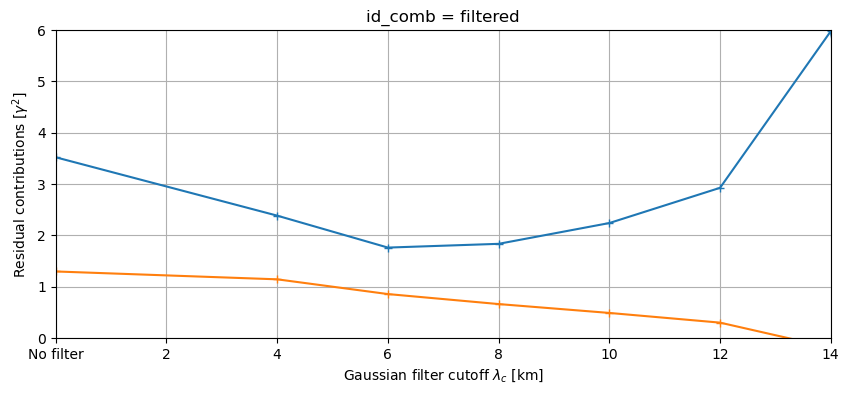

In [36]:
from matplotlib.gridspec import GridSpec

fig, ax = plt.subplots(1, 1, frameon=False, figsize = (10, 4))
rc = (dsgc.E_ggd/(dsgc.B_ggd -ds4.sel(altiprod='L4_withnadirswot').B_ggd).values)
rf = (dsgf.E_ggd/(dsgf.B_ggd -ds4.sel(altiprod='L4_withnadirswot').B_ggd).values)

rc.plot(ax=ax, label = 'L3-2km calibrated', marker='+')
rf.plot(ax=ax, label = 'L3-2km calibrated', marker='+')
ax.set_xlim(0,14)
ax.set_ylabel(r'Residual contribution over the difference with L4')
ax.grid()
a=ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[0]='No filter'
ax.set_xticklabels(a)
ax.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
ax.set_ylim(0, 6)
ax.set_title('')


In [23]:
a

<xarray.DataArray 'E_ggd' (cutoff: 17)> Size: 136B
array([ 3.51876144,  2.3820807 ,  1.75988722,  1.83289166,  2.23780482,
        2.92414556,  5.97463575, -6.53226706, -1.44437403, -0.65376233,
       -0.18687006, -0.09318538, -0.06693631, -0.05651893, -0.0498509 ,
       -0.04404519, -0.0385954 ])
Coordinates:
    id_comb  <U10 40B 'calibrated'
  * cutoff   (cutoff) float64 136B 0.0 4.0 6.0 8.0 10.0 ... 40.0 45.0 50.0 55.0

In [ ]:

# Exponential fit
b_exp_fit.plot(ax=ax, ls=':', color = 'b', label = rf'{round(b_exp_popt[0])} exp(-$\lambda_c$/{round(b_exp_popt[1])})')
ig.plot(ax=ax, ls=':', color = 'k', label = rf'$\lambda^{-2}$ fit')
# best fit but not exponenetial
#e_fit.sel(cutoff = slice(5, 55)).plot(ax=ax, ls=':',color = 'k', label = rf'{round(e_popt[0])} exp(-$\lambda_c$/{round(e_popt[1])}) - {round(e_popt[2])}/$\lambda_c^{round(e_popt[3])}$')

ax.scatter(0, ds4.isel(altiprod=0).B_ggd, marker = '*', c=c0['ggd'])
ax.scatter(0, ds4.isel(altiprod=0).E_ggd, marker = '*', c='grey')
#dsg.GGD.plot(ax=ax, label = 'MS')

for ap in ds4.altiprod.values[3:4]:
    ax.axhline(ds4.sel(altiprod=ap).B_ggd, ls='--',  color=c0['ggd'], label = ap + ' Balanced contribution')
    #ax.annotate(ap, (40,ds4.sel(altiprod=ap).B_ggd+0.02))
    #ax.axhline(ds4.sel(altiprod=ap.values).E_ggd, ls=':', color='orange')

    #ax.axhline(ds4.sel(altiprod=ap.values).GGD, ls=':', label=ap.values, color='orange')

ax.set_xlim(-1, 57)

a=ax.get_xticks().tolist()
a = [int(a_) for a_ in a]
a[1]='No filter'

ax.set_xticklabels(a)
ax.set_xlabel(r'Gaussian filter cutoff $\lambda_c$ [km]')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_ylim(-0.5,4)


Text(0, 0.5, '[$\\gamma^2$]')

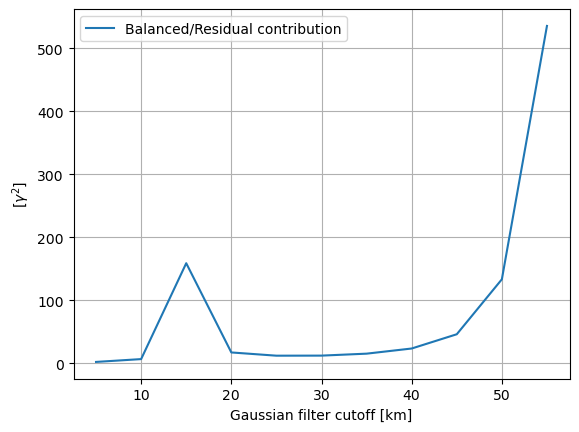

In [219]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
abs(dsg.B_ggd/dsg.E_ggd).plot(ax=ax, label = 'Balanced/Residual contribution')
ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

# Theoritical -> not the good model 

In [158]:
dsms = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', 'ms_noise_gaussian.nc'))
dsms['cutoff'] = dsms['cutoff']/1000

Text(0, 0.5, '[$\\gamma^2$]')

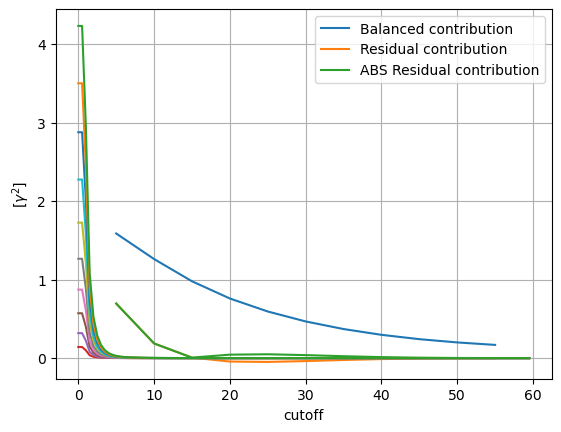

In [162]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsg.B_ggd.plot(ax=ax, label = 'Balanced contribution')
dsg.E_ggd.plot(ax=ax, label = 'Residual contribution')
abs(dsg.E_ggd).plot(ax=ax, label = 'ABS Residual contribution')
dsms.ms_noise_ggd.plot(hue='sigmassh', ax=ax)
#dsg.GGD.plot(ax=ax, label = 'MS')
#ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km1)), ls='--', label = 'sig3km = 0.4 cm')
#ax.plot(ct, varggd_from_sigmassh(sigmassh(ct, sig3km=sig3km2)), ls='--', label = 'sig3km = 0.25 cm')
#e_fit.plot(ls=':', label = rf'{np.round(e_popt[0])}exp(-{np.round(e_popt[1], 2)}$\lambda_c$) - {np.round(e_popt[2], 2)}/$\lambda_c$^{np.round(e_popt[3], 2)}')
#b_fit.plot(ls=':')
#b_exp_fit.plot(ls=':', label = rf'{np.round(b_exp_popt[0])}exp(-{np.round(b_exp_popt[1], 2)}$\lambda_c$)')
#g_exp_fit.plot(ls=':', label = rf'{np.round(g_exp_popt[0])}exp(-{np.round(g_exp_popt[1], 4)}*$\lambda_c$)')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')

## Other quantities

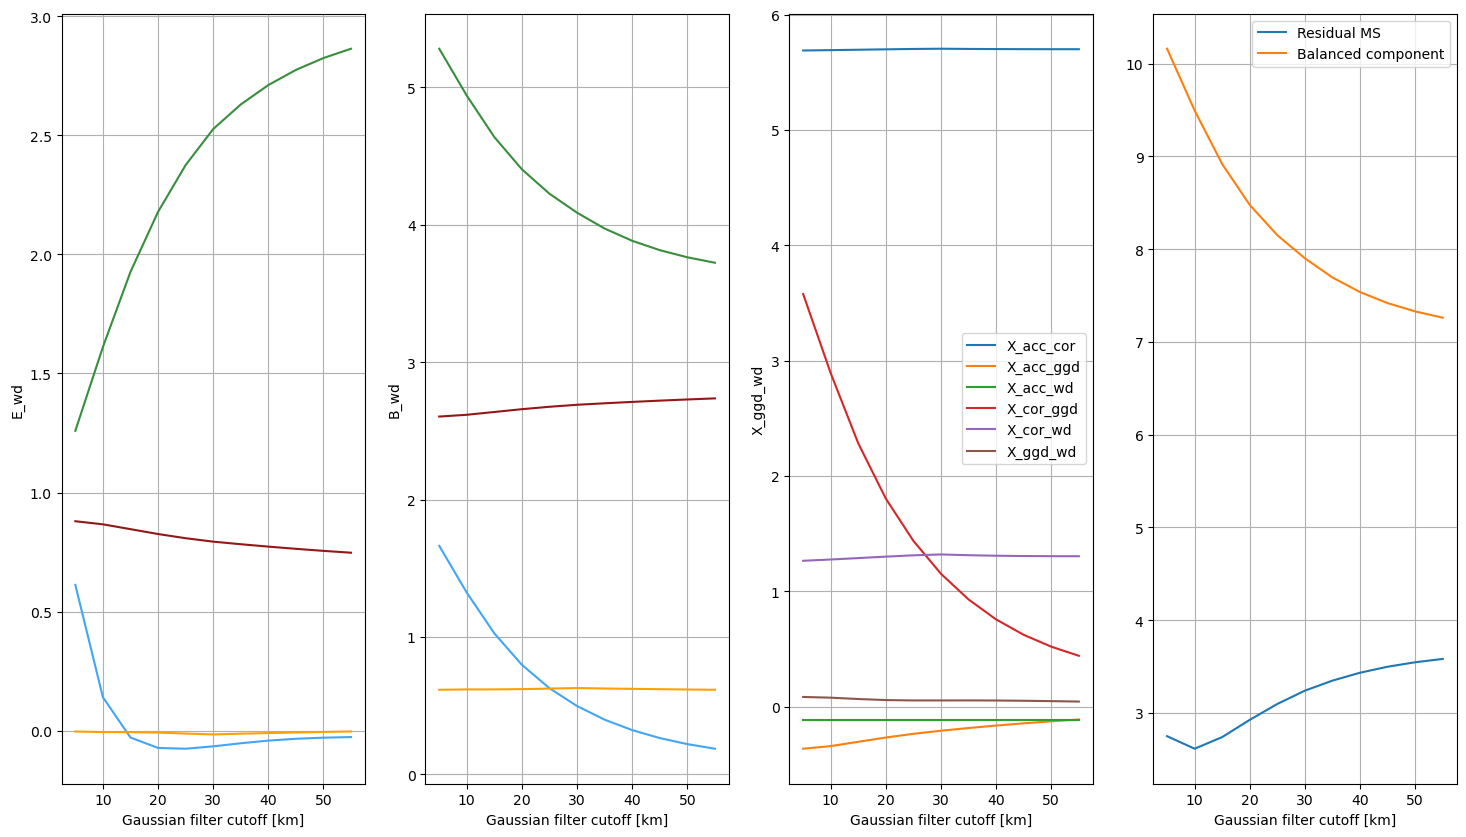

In [13]:
fig, axs = plt.subplots(1,4, figsize=(18, 10))
ax=axs[0]
for v in ['acc', 'ggd', 'cor', 'wd'] :
    dsg['E_'+v].plot(color=c0[v], ax=ax)
ax=axs[1]
for v in ['acc', 'ggd', 'cor', 'wd'] :
    dsg['B_'+v].plot(color=c0[v], ax=ax)
ax=axs[2]
for v in [v for v in dsg if ('X_' in v)&('ser__' not in v)]: 
    dsg[v].plot(label=v, ax=ax)
    ax.legend()

ax=axs[3]
dsg.S.plot( ax=ax, label='Residual MS') 
(sum([dsg['B_'+v] for v in ['acc', 'ggd', 'cor', 'wd']])).plot(ax=ax, label='Balanced component') 
ax.legend()

for ax in axs :
    ax.grid()

# Fitting kernel - Not working

In [5]:
#FITTING KERNEL
npts = np.arange(5, 19, 2)

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fitting_kernel',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',npts)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, dict(alti_diff_method_param = int(npt))) for npt in npts]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',npts)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSF = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)


DSF = DSF.rename({'id_comb':'npts'})
DSF['npts'] = DSF.npts
DSF['npts'] = DSF['npts'].assign_attrs({'long_name': 'Fitting kernel number of points', 'units':'npts'})


# Closure figs
dsf = compute_mean_square(DSF)/U2


289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio0
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio0
264246
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_9_etaf__era5_rio0
250794
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_11_etaf__era5_rio0
237840
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_13_etaf__era5_rio0
223946
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_15_etaf__era5_rio0
210192
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_17_etaf__era5_rio0
Identified SWOT and drifter outliers have been removed
289188
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_5_etaf__era5_rio15
276889
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fitting_kernel_7_etaf__era5_rio15
264246
12h_spectral_decomp_all_med_vari

Text(0, 0.5, '[$\\gamma^2$]')

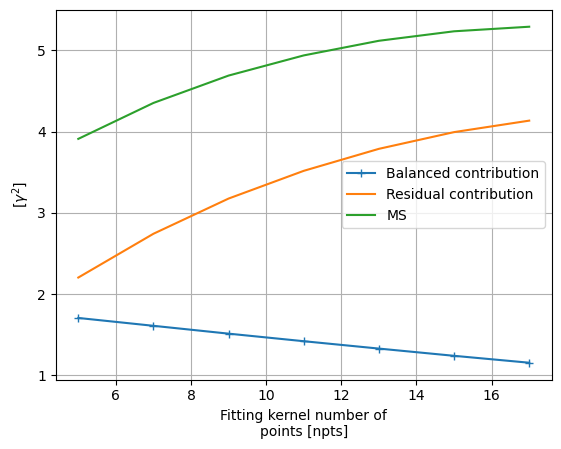

In [6]:
fig, ax = plt.subplots(1,1)
#ax = axs[0]
dsf.B_ggd.plot(ax=ax, label = 'Balanced contribution', marker='+')
dsf.E_ggd.plot(ax=ax, label = 'Residual contribution')
dsf.GGD.plot(ax=ax, label = 'MS')

ax.grid()
ax.legend()
ax.set_ylabel(r'[$\gamma^2$]')